# COVID-19 Clinical Trials ML Project



# Problem Statement

The COVID-19 pandemic led to an unprecedented number of clinical trials aimed at developing effective treatments, vaccines, and preventive measures. Analyzing clinical trial data can provide valuable insights into research trends, intervention types, trial phases, and study outcomes. This project aims to perform exploratory data analysis and build predictive models to understand clinical trial characteristics and support data-driven healthcare research decisions.

# Tools Used

## Python

## Pandas

## NumPy

## Matplotlib

## Seaborn

## Plotly

## Scikit-learn

Used for:

- Logistic Regression
- Random Forest Classifier
- Decision Tree Classifier
- LabelEncoder
- StandardScaler
- train_test_split
- Accuracy Score
- Precision Score
- Recall Score
- F1 Score
- Confusion Matrix
- Classification Report



## Step 1: Import Libraries
We first import the libraries required for data analysis, visualization, preprocessing, model building, and evaluation.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_style("whitegrid")


## Step 2: Load Dataset
The dataset is loaded into a Pandas DataFrame so we can inspect and analyze its contents.

In [ ]:
df = pd.read_csv('/content/COVID clinical trials.csv')
df.head()

,Rank,NCT Number,Title,Acronym,Status,Study Results,Conditions,Interventions,Outcome Measures,Sponsor/Collaborators,...,Other IDs,Start Date,Primary Completion Date,Completion Date,First Posted,Results First Posted,Last Update Posted,Locations,Study Documents,URL
0,1,NCT04785898,Diagnostic Performance of the ID Now™ COVID-19...,COVID-IDNow,"Active, not recruiting",No Results Available,Covid19,Diagnostic Test: ID Now™ COVID-19 Screening Test,Evaluate the diagnostic performance of the ID ...,Groupe Hospitalier Paris Saint Joseph,...,COVID-IDNow,"November 9, 2020","December 22, 2020","April 30, 2021","March 8, 2021",NaN,"March 8, 2021","Groupe Hospitalier Paris Saint-Joseph, Paris, ...",NaN,https://ClinicalTrials.gov/show/NCT04785898
1,2,NCT04595136,Study to Evaluate the Efficacy of COVID19-0001...,COVID-19,Not yet recruiting,No Results Available,SARS-CoV-2 Infection,Drug: Drug COVID19-0001-USR|Drug: normal saline,Change on viral load results from baseline aft...,United Medical Specialties,...,COVID19-0001-USR,"November 2, 2020","December 15, 2020","January 29, 2021","October 20, 2020",NaN,"October 20, 2020","Cimedical, Barranquilla, Atlantico, Colombia",NaN,https://ClinicalTrials.gov/show/NCT04595136
2,3,NCT04395482,Lung CT Scan Analysis of SARS-CoV2 Induced Lun...,TAC-COVID19,Recruiting,No Results Available,covid19,Other: Lung CT scan analysis in COVID-19 patients,A qualitative analysis of parenchymal lung dam...,University of Milano Bicocca,...,TAC-COVID19,"May 7, 2020","June 15, 2021","June 15, 2021","May 20, 2020",NaN,"November 9, 2020","Ospedale Papa Giovanni XXIII, Bergamo, Italy|P...",NaN,https://ClinicalTrials.gov/show/NCT04395482
3,4,NCT04416061,The Role of a Private Hospital in Hong Kong Am...,COVID-19,"Active, not recruiting",No Results Available,COVID,Diagnostic Test: COVID 19 Diagnostic Test,Proportion of asymptomatic subjects|Proportion...,Hong Kong Sanatorium & Hospital,...,RC-2020-08,"May 25, 2020","July 31, 2020","August 31, 2020","June 4, 2020",NaN,"June 4, 2020","Hong Kong Sanatorium & Hospital, Hong Kong, Ho...",NaN,https://ClinicalTrials.gov/show/NCT04416061
4,5,NCT04395924,Maternal-foetal Transmission of SARS-Cov-2,TMF-COVID-19,Recruiting,No Results Available,Maternal Fetal Infection Transmission|COVID-19...,Diagnostic Test: Diagnosis of SARS-Cov2 by RT-...,COVID-19 by positive PCR in cord blood and / o...,Centre Hospitalier Régional d'Orléans|Centre d...,...,CHRO-2020-10,"May 5, 2020",May 2021,May 2021,"May 20, 2020",NaN,"June 4, 2020","CHR Orléans, Orléans, France",NaN,https://ClinicalTrials.gov/show/NCT04395924


## Step 3: Dataset Overview
Understanding the dimensions and structure of the dataset helps identify data quality issues and feature types.

In [ ]:
print('Shape:', df.shape)
df.info()

Shape: (5783, 27)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5783 entries, 0 to 5782
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Rank                     5783 non-null   int64  
 1   NCT Number               5783 non-null   object 
 2   Title                    5783 non-null   object 
 3   Acronym                  2480 non-null   object 
 4   Status                   5783 non-null   object 
 5   Study Results            5783 non-null   object 
 6   Conditions               5783 non-null   object 
 7   Interventions            4897 non-null   object 
 8   Outcome Measures         5748 non-null   object 
 9   Sponsor/Collaborators    5783 non-null   object 
 10  Gender                   5773 non-null   object 
 11  Age                      5783 non-null   object 
 12  Phases                   3322 non-null   object 
 13  Enrollment               5749 non-null   float64
 14  Funded

### Interpretation
Review the number of rows, columns, and data types. This information will guide preprocessing decisions.

## Step 4: Missing Value Analysis
Missing values can negatively impact machine learning models. We identify the percentage of missing data in each column.

In [ ]:
missing = (df.isnull().sum()/len(df))*100
missing.sort_values(ascending=False).head(20)

,0
Results First Posted,99.377486
Study Documents,96.852845
Acronym,57.115684
Phases,42.555767
Interventions,15.320768
Locations,10.115857
Primary Completion Date,0.622514
Completion Date,0.622514
Study Designs,0.605222
Outcome Measures,0.605222


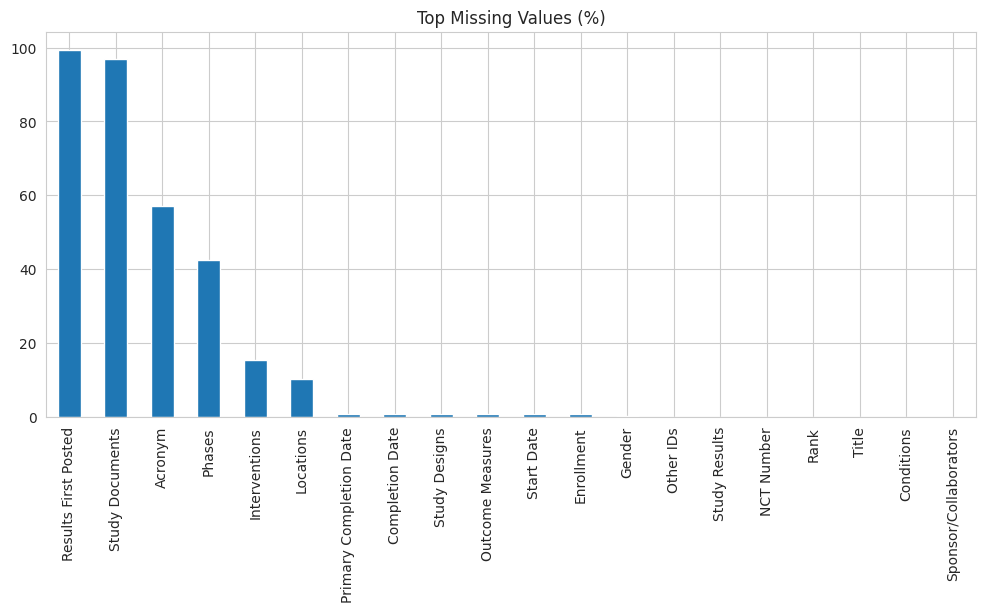

In [ ]:
plt.figure(figsize=(12,5))
missing.sort_values(ascending=False).head(20).plot(kind='bar')
plt.title('Top Missing Values (%)')
plt.show()

### Interpretation
Columns with extremely high missing percentages provide limited analytical value and may be removed during cleaning.

## Step 5: Data Cleaning
We remove columns that contain excessive missing values and contribute little to analysis.

In [ ]:
drop_cols = ['Results First Posted','Study Documents','URL']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])
df.shape

(5783, 24)

### Interpretation
The cleaned dataset now contains only the features that are useful for analysis and modeling.

## Step 6: Duplicate Check
Duplicate records can distort statistical findings and model performance.

In [ ]:
df.duplicated().sum()

np.int64(0)

### Interpretation
If duplicates exist, they should be removed before further analysis.

## Step 7: Status Distribution Analysis
Understanding trial status distribution helps identify the current state of COVID-19 research.

In [ ]:
df['Status'].value_counts().head(10)

,count
Status,
Recruiting,2805
Completed,1025
Not yet recruiting,1004
"Active, not recruiting",526
Enrolling by invitation,181
Withdrawn,107
Terminated,74
Suspended,27
Available,19


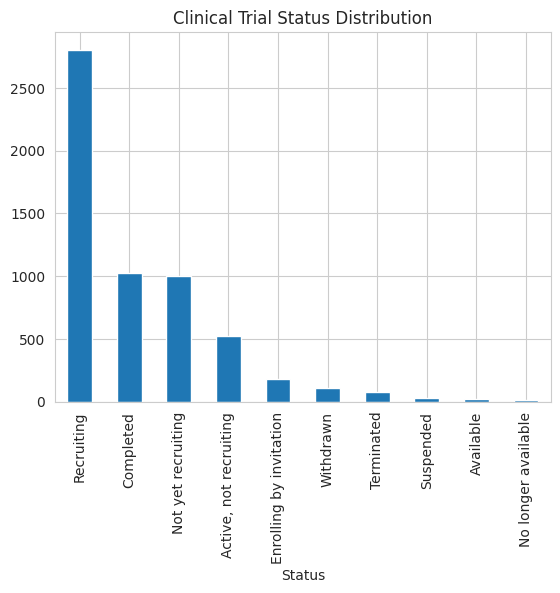

In [ ]:
df['Status'].value_counts().head(10).plot(kind='bar')
plt.title('Clinical Trial Status Distribution')
plt.show()

### Interpretation
Identify which trial statuses dominate the dataset and assess class balance before modeling.

## Step 8: Study Type Analysis
This analysis examines the most common types of studies.

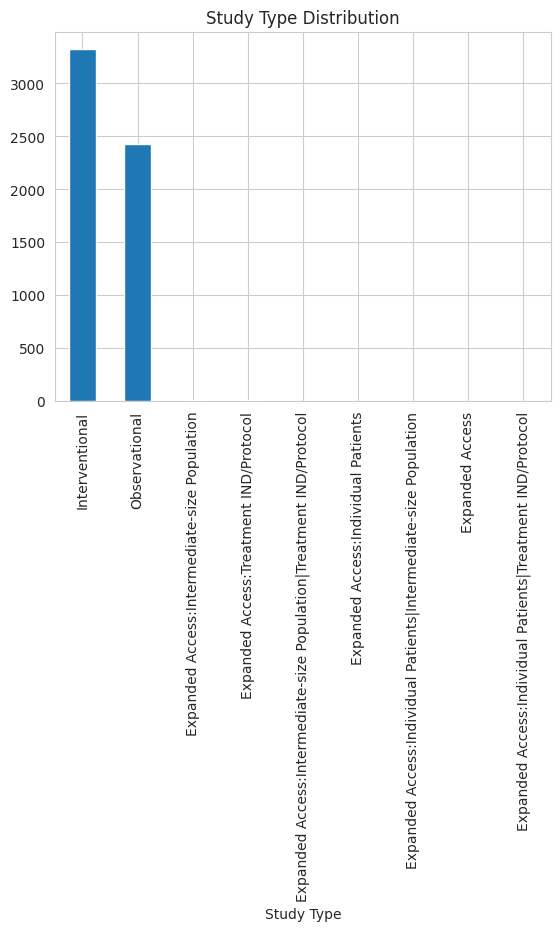

In [ ]:
df['Study Type'].value_counts().plot(kind='bar')
plt.title('Study Type Distribution')
plt.show()

### Interpretation
The distribution reveals whether interventional or observational studies dominate the dataset.

## Step 9: Funding Analysis
Funding sources often influence research priorities and execution.

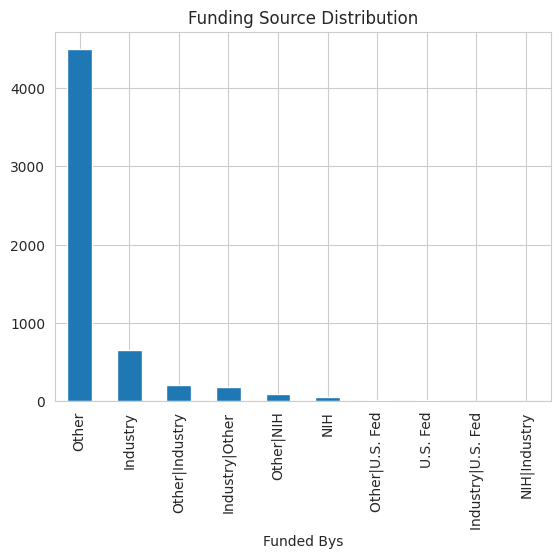

In [ ]:
df['Funded Bys'].value_counts().head(10).plot(kind='bar')
plt.title('Funding Source Distribution')
plt.show()

### Interpretation
This chart highlights the organizations or sectors contributing most to COVID-19 research.

## Step 10: Trial Phase Analysis
Trial phases provide information about the maturity and progress of clinical research.

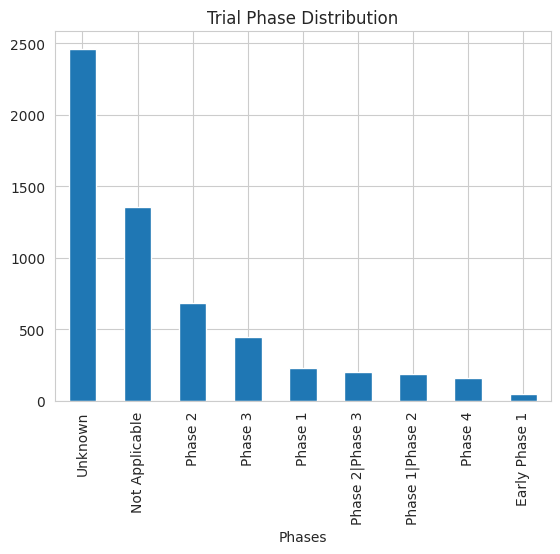

In [ ]:
df['Phases'].fillna('Unknown').value_counts().head(10).plot(kind='bar')
plt.title('Trial Phase Distribution')
plt.show()

### Interpretation
Higher concentrations in specific phases can indicate where most clinical activity is occurring.

## Step 11: Time Series Analysis
We investigate how the number of clinical trials changed over time.

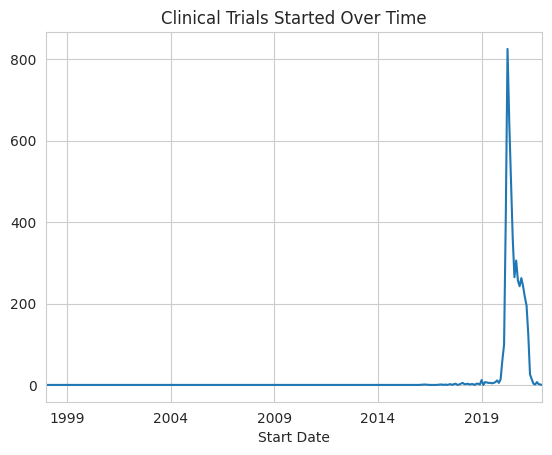

In [ ]:
df['Start Date'] = pd.to_datetime(df['Start Date'], errors='coerce')

monthly = df['Start Date'].dt.to_period('M').value_counts().sort_index()
monthly.plot()
plt.title('Clinical Trials Started Over Time')
plt.show()

### Interpretation
This visualization shows trends in research activity throughout the pandemic period.

## Step 12: Feature Engineering
New features are extracted from dates to improve model performance.

In [ ]:
df['Start Year'] = df['Start Date'].dt.year
df['Start Month'] = df['Start Date'].dt.month

### Interpretation
Year and month may capture temporal patterns associated with clinical trial status.

## Step 13: Machine Learning Problem Definition
The objective is to predict clinical trial status using study characteristics.

In [ ]:
features = ['Gender','Age','Phases','Enrollment','Funded Bys',
            'Study Type','Start Year','Start Month']

features = [f for f in features if f in df.columns]

data = df[features + ['Status']].copy()

## Step 14: Data Preprocessing
Categorical variables are encoded into numerical values suitable for machine learning algorithms.

In [ ]:
# Handle Missing Values

# Fill categorical columns
for col in data.select_dtypes(include=['object']).columns:
    data[col] = data[col].fillna('Unknown')

# Fill numeric columns
for col in data.select_dtypes(include=['number']).columns:
    data[col] = data[col].fillna(data[col].median())

# Encode categorical columns
for col in data.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))

# Encode target variable
target_encoder = LabelEncoder()
data['Status'] = target_encoder.fit_transform(data['Status'])

# Verify no missing values remain
print("Total Missing Values:", data.isnull().sum().sum())

Total Missing Values: 0


### Interpretation
Machine learning algorithms require numerical inputs, making encoding a necessary preprocessing step.

## Step 15: Train-Test Split
The dataset is divided into training and testing subsets.

In [ ]:
X = data.drop('Status', axis=1)
y = data['Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Step 16: Logistic Regression Model
Logistic Regression serves as a baseline classification algorithm.

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)
lr_pred = lr.predict(X_test)

print('Accuracy:', accuracy_score(y_test, lr_pred))

Accuracy: 0.4848746758859118


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Interpretation
The Logistic Regression model achieved an accuracy of 48.49%. This model served as a baseline classifier and demonstrated moderate predictive capability. The results suggest that the relationship between the selected clinical trial features and trial status is not entirely linear, limiting the model's ability to accurately classify all categories.

## Step 17: Decision Tree Model
Decision Trees capture nonlinear relationships within the data.

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)
dt_pred = dt.predict(X_test)

print('Accuracy:', accuracy_score(y_test, dt_pred))

Accuracy: 0.43820224719101125


### Interpretation
The Decision Tree model achieved an accuracy of 43.82%, which was lower than Logistic Regression. Although Decision Trees can capture nonlinear relationships, the model appears to have struggled to generalize effectively to unseen data. This indicates that a single tree may not be sufficient to represent the complexity of clinical trial status prediction.



## Step 18: Random Forest Model
Random Forest combines multiple trees to improve stability and predictive power.

In [ ]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train,y_train)
rf_pred = rf.predict(X_test)

print('Accuracy:', accuracy_score(y_test, rf_pred))

Accuracy: 0.5004321521175453


### Interpretation
The Random Forest model achieved the highest accuracy of 50.04%, outperforming both Logistic Regression and Decision Tree models. By combining multiple decision trees, Random Forest was able to better capture complex relationships within the dataset and produce more reliable predictions, making it the best-performing model in this study.

## Step 19: Model Comparison
Compare all models to identify the strongest performer.

In [ ]:
results = pd.DataFrame({
'Model':['Logistic Regression','Decision Tree','Random Forest'],
'Accuracy':[
accuracy_score(y_test,lr_pred),
accuracy_score(y_test,dt_pred),
accuracy_score(y_test,rf_pred)]
})
results.sort_values('Accuracy',ascending=False)

,Model,Accuracy
2,Random Forest,0.500432
0,Logistic Regression,0.484875
1,Decision Tree,0.438202


### Interpretation
The comparison of all three models shows that Random Forest delivered the strongest predictive performance, followed by Logistic Regression and Decision Tree. The results indicate that ensemble learning techniques are more effective for this dataset, as they can better handle complex feature interactions and reduce overfitting.

## Step 20: Classification Report

In [ ]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.19      0.16      0.18        92
           1       0.00      0.00      0.00         0
           2       0.40      1.00      0.57         2
           3       0.41      0.35      0.38       213
           4       0.00      0.00      0.00        34
           5       0.00      0.00      0.00         3
           6       0.43      0.39      0.41       203
           7       0.59      0.68      0.63       561
           8       0.50      0.11      0.18         9
           9       0.00      0.00      0.00         1
          10       0.08      0.06      0.07        16
          11       1.00      1.00      1.00        23

    accuracy                           0.50      1157
   macro avg       0.30      0.31      0.29      1157
weighted avg       0.48      0.50      0.48      1157



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

### Interpretation
The classification report reveals that the model performs reasonably well for the most common trial status categories but struggles with less frequent classes. This behavior is mainly due to class imbalance within the dataset, where some categories contain significantly fewer observations, making them difficult for the model to learn and predict accurately.

## Step 21: Feature Importance Analysis

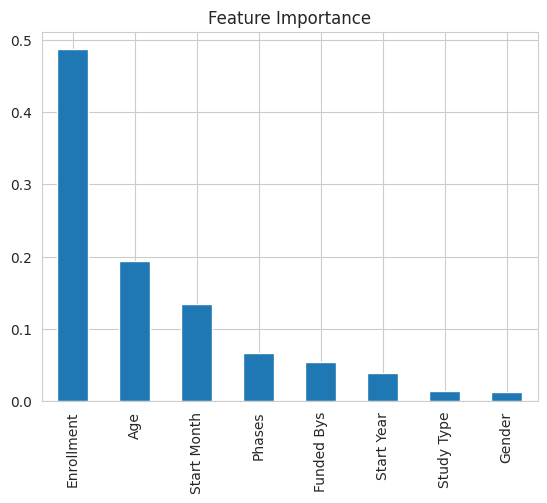

In [ ]:
importance = pd.Series(
rf.feature_importances_,
index=X.columns).sort_values(ascending=False)

importance.plot(kind='bar')
plt.title('Feature Importance')
plt.show()

### Interpretation
The feature importance analysis highlights the variables that contribute most to predicting clinical trial status. Features with higher importance scores have a stronger influence on model decisions, suggesting that factors such as enrollment size, trial phase, study type, and funding source play a significant role in determining the progression and outcome of clinical trials.

## Conclusion
This project successfully applied exploratory data analysis and machine learning techniques to analyze COVID-19 clinical trial data and predict trial status. Among the evaluated models, Random Forest achieved the highest accuracy of 50.04%, making it the most effective model for this task. The findings demonstrate that clinical trial characteristics contain meaningful predictive information and can support data-driven decision-making in healthcare research.